In [1]:
import pandas as pd
from main import *
from io import StringIO
from data import *
from model import *
import matplotlib.pyplot as plt

/Users/jlawson/Documents/LastManStanding/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jlawson/Documents/LastManStanding/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
matches = get_matches()

upcoming_match_odds = get_upcoming_match_odds()
upcoming_match_odds_lookup = {
    (m["date_id"], m["home_team"], m["away_team"]): (m["p_home"], m["p_away"])
    for m in upcoming_match_odds
}

elos = get_elos()

In [3]:
matches_with_bf_odds = []

for match in matches:
    date_id = match["date_id"]
    home_team = match["home_team"]
    away_team = match["away_team"]
    if (match['score_home'] is None) and (date_id, home_team, away_team) in upcoming_match_odds_lookup:
        match_copy = deepcopy(match)

        match_copy['p_home_betfair'], match_copy['p_away_betfair'] = upcoming_match_odds_lookup[
            (date_id, home_team, away_team)
        ]
        
        match_copy['p_home_elo'], match_copy['p_away_elo'] = elos_to_modelled_probabilities(elos[home_team], elos[away_team])
        
        matches_with_bf_odds.append(match_copy)

matches_with_bf_odds = pd.DataFrame(matches_with_bf_odds)

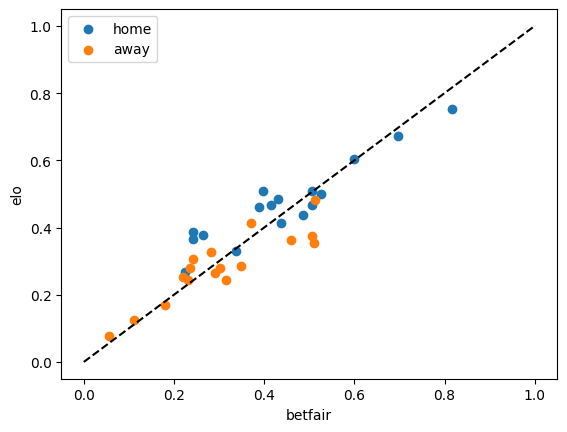

In [4]:
plt.scatter(matches_with_bf_odds['p_home_betfair'], matches_with_bf_odds['p_home_elo'], label='home')
plt.scatter(matches_with_bf_odds['p_away_betfair'], matches_with_bf_odds['p_away_elo'], label='away')
plt.plot([0, 1], [0, 1], linestyle='--', color='k')
plt.xlabel('betfair')
plt.ylabel('elo')
plt.legend();